In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

seed = 67

In [2]:
def power_method(A):
    n, m = A.shape
    x = np.ones((n, 1))
    lambda_o = 0

    for i in range(100):
        x_p = A @ x
        lambda_n = np.linalg.norm(x_p.flatten(), 2)

        x_p /= lambda_n

        if np.linalg.norm(x_p - x, np.inf) < 1e-5:
            return lambda_n, x_p

        lambda_o = lambda_n
        x = x_p
    
    return lambda_o, x

In [3]:
def to_stochastic_form(M):
    A = np.zeros_like(M)

    N = np.sum(M, axis = 0) #Number of outer edges
    N = np.transpose(N)

    A = M/N

    return A

In [4]:
def test(M):
    #Converting to stochastic form
    M = to_stochastic_form(M)

    #Get eigen_values from power method and numpy
    eigen_val, eigen_vec = power_method(M)
    real_eigen_val, real_eigen_vec = np.linalg.eig(M)

    #Get first eigen val and eigen vec
    max_arg = np.argmax(np.abs(real_eigen_val))

    #Numpy returns in complex numbers, so we have to take only real part
    v_real = np.real(real_eigen_vec[:, max_arg]).flatten()
    v_power = eigen_vec.flatten()

    #Diffrence between real values and that counted by our implemenation
    print(f"Eigen Val DIFF: {abs(real_eigen_val[max_arg] - eigen_val)}")
    
    #Diff between eigen vectors(normalized)
    print(f"Vector DIFF: {np.linalg.norm(np.abs(v_real) - np.abs(v_power), np.inf)}")

    ############################################################
    #               Cosine similarity metrics                  #
    ############################################################

    dot_product = np.dot(v_real, v_power)

    norm_real = np.linalg.norm(v_real)
    norm_power = np.linalg.norm(v_power)

    cosine_similarity = dot_product / (norm_real * norm_power)

    cosine_distance = 1.0 - np.abs(cosine_similarity)

    print(f"Cosine similarity: {cosine_distance:.2e}")

Eigen Val DIFF: 1.071379056249988e-06
Vector DIFF: 3.5265976588982895e-06
Cosine similarity: 2.34e-11


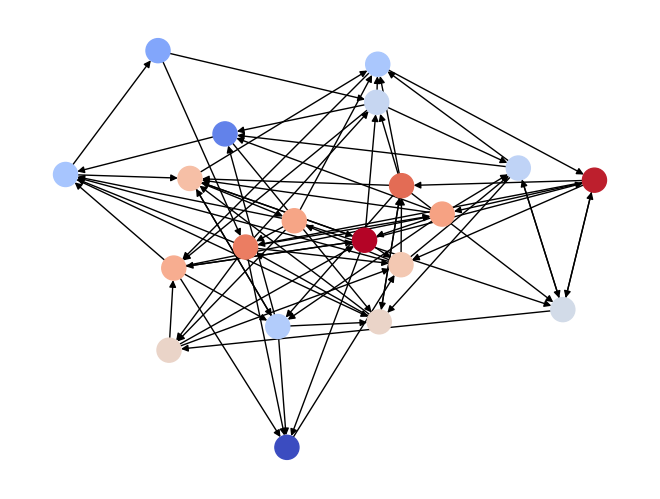

In [5]:
V = 20
p = 0.2

G = nx.gnp_random_graph(V, p, directed=True)

M = nx.to_numpy_array(G)

test(M)

_, eigen_vec = power_method(M)

nx.draw(
    G,
    node_color = eigen_vec,
    cmap = plt.cm.coolwarm,
)

plt.show()

Eigen Val DIFF: 1.1533744401770463e-06
Vector DIFF: 6.819366151866735e-05
Cosine similarity: 1.54e-08


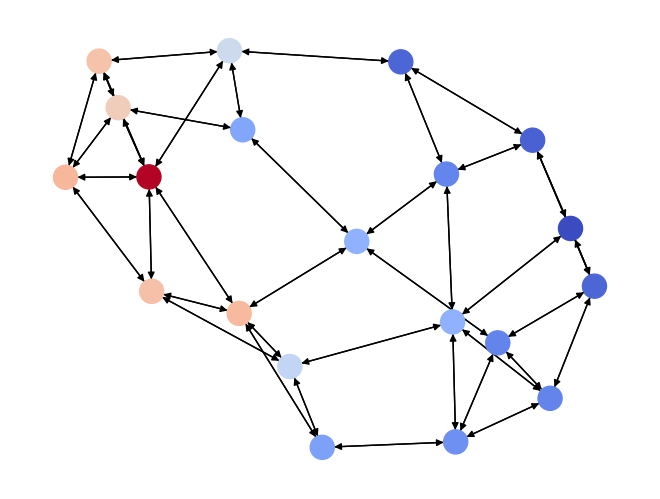

In [6]:
G = nx.watts_strogatz_graph(n=20, k=4, p=0.2, seed=seed).to_directed()
M = nx.to_numpy_array(G)
test(M)

_, eigen_vec = power_method(M)

nx.draw(
    G,
    node_color = eigen_vec,
    cmap = plt.cm.coolwarm,
)

plt.show()

Eigen Val DIFF: 0.001461638326965442
Vector DIFF: 0.02028708645643365
Cosine similarity: 1.22e-03


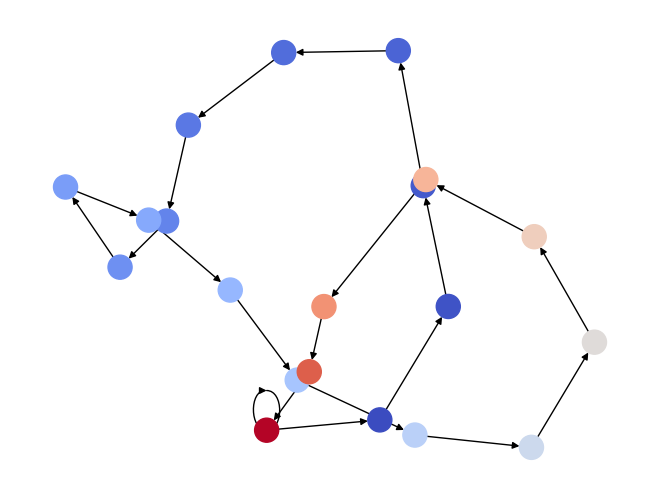

In [7]:
G = nx.cycle_graph(20, create_using=nx.DiGraph)

for _ in range(20):
    p, q = 0, 0
    while p != q:
        p = np.random.randint(0, 20)
        q = np.random.randint(0, 20)
    
    G.add_edge(p, q)

M = nx.to_numpy_array(G)
test(M)

_, eigen_vec = power_method(M)

nx.draw(
    G,
    node_color = eigen_vec,
    cmap = plt.cm.coolwarm,
)

plt.show()